# Decision Tree & Binary Classification
Perform binary classification on a modified version of the Iris dataset (removing one class) using a default scikit-learn Decision Tree classifier. Evaluate the model by calculating and displaying the classification report (precision, recall, accuracy, F1 score), generating a confusion matrix, and plotting the ROC curve.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

filtered_df = df[df['target'] != 2].copy()

display(filtered_df.head())

display(filtered_df['target'].value_counts())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,count
target,
0,50
1,50


In [ ]:
from sklearn.model_selection import train_test_split

X = filtered_df.drop('target', axis=1)
y = filtered_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(X_train.head())
display(X_test.head())
display(y_train.head())
display(y_test.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
55,5.7,2.8,4.5,1.3
88,5.6,3.0,4.1,1.3
26,5.0,3.4,1.6,0.4
42,4.4,3.2,1.3,0.2
69,5.6,2.5,3.9,1.1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
83,6.0,2.7,5.1,1.6
53,5.5,2.3,4.0,1.3
70,5.9,3.2,4.8,1.8
45,4.8,3.0,1.4,0.3
44,5.1,3.8,1.9,0.4


,target
55,1
88,1
26,0
42,0
69,1


,target
83,1
53,1
70,1
45,0
44,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Confusion Matrix:


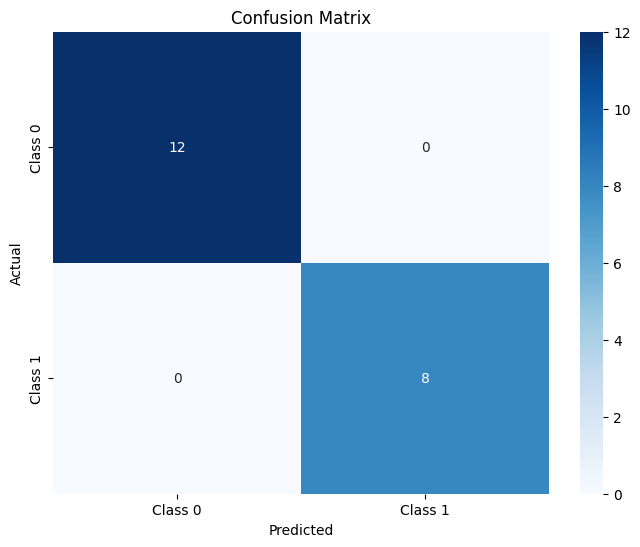

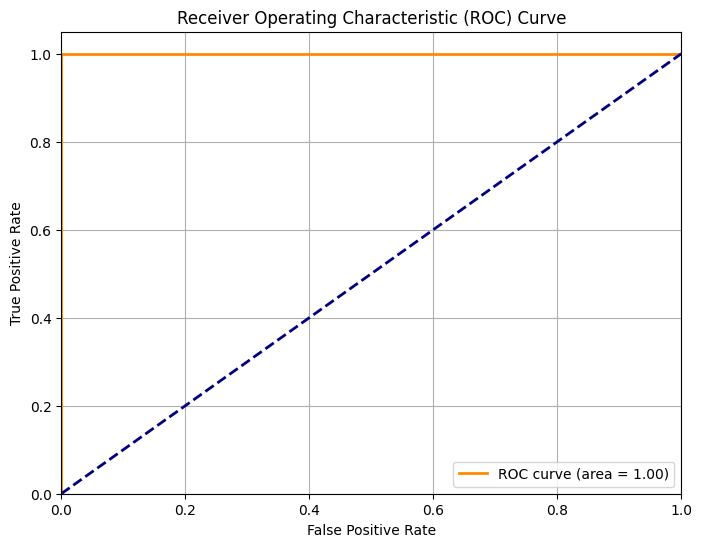

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# CART and ID3 using Sklearn -
Perform classification on the full Iris dataset using scikit-learn's default Decision Tree implementation with both the Gini (CART) and Entropy (ID3) criteria. For each method, generate a confusion matrix heatmap and print a classification report.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df_full = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_full['target'] = iris.target

display(df_full.head())
display(df_full['target'].value_counts())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,count
target,
0,50
1,50
2,50


In [ ]:
from sklearn.model_selection import train_test_split

X_full = df_full.drop('target', axis=1)
y_full = df_full['target']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

display(X_train_full.head())
display(X_test_full.head())
display(y_train_full.head())
display(y_test_full.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4


,target
22,0
15,0
65,1
11,0
42,0


,target
73,1
18,0
118,2
78,1
76,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train_full, y_train_full)

DecisionTreeClassifier(random_state=42)

Classification Report (CART):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix (CART):


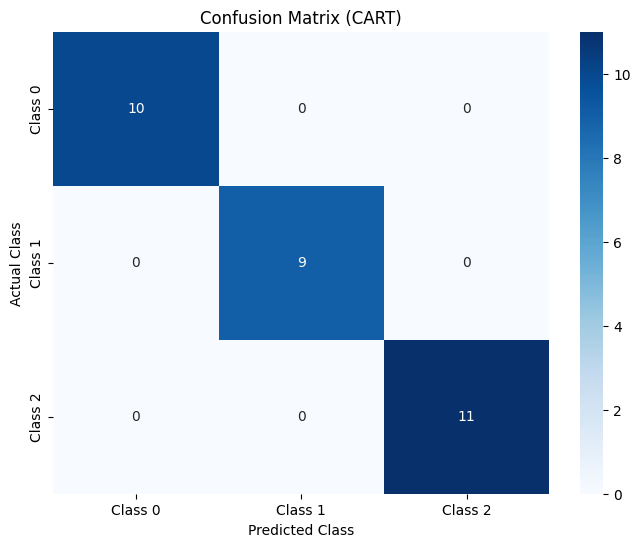

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_gini = model_gini.predict(X_test_full)

print("Classification Report (CART):")
print(classification_report(y_test_full, y_pred_gini))

print("\nConfusion Matrix (CART):")
cm_gini = confusion_matrix(y_test_full, y_pred_gini)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (CART)')
plt.show()

In [ ]:
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train_full, y_train_full)

DecisionTreeClassifier(criterion='entropy', random_state=42)

Classification Report (ID3):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix (ID3):


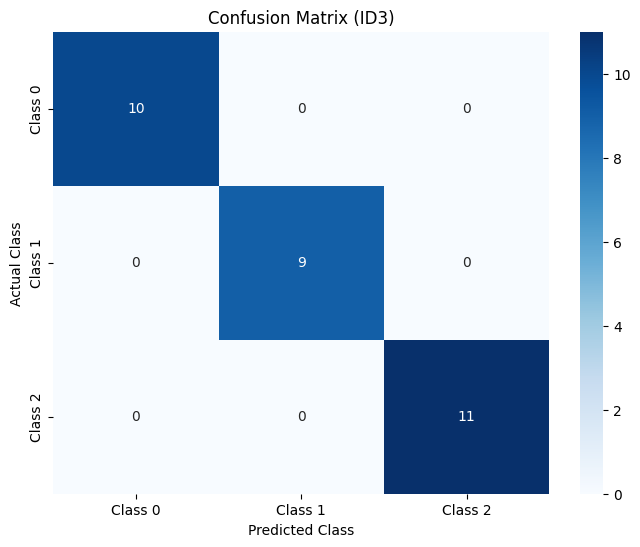

In [ ]:
y_pred_entropy = model_entropy.predict(X_test_full)

print("Classification Report (ID3):")
print(classification_report(y_test_full, y_pred_entropy))

print("\nConfusion Matrix (ID3):")
cm_entropy = confusion_matrix(y_test_full, y_pred_entropy)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (ID3)')
plt.show()

# C4.5 by tuning the value of ccp_alpha -
Perform C4.5 classification on the iris dataset (all 3 flowers) using scikit-learn's Decision Tree by tuning the `ccp_alpha` parameter. After training, generate a confusion matrix heatmap and a classification report.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

path = model_gini.cost_complexity_pruning_path(X_train_full, y_train_full)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

mean_cv_scores = []
for ccp_alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)
    scores = cross_val_score(model, X_train_full, y_train_full, cv=5, scoring='accuracy')
    mean_cv_scores.append(scores.mean())

optimal_alpha_index = mean_cv_scores.index(max(mean_cv_scores))
optimal_ccp_alpha = ccp_alphas[optimal_alpha_index]

print(f"Optimal ccp_alpha: {optimal_ccp_alpha}")

Optimal ccp_alpha: 0.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_c45 = DecisionTreeClassifier(criterion='entropy', ccp_alpha=optimal_ccp_alpha, random_state=42)
model_c45.fit(X_train_full, y_train_full)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), criterion='entropy',
                       random_state=42)

Classification Report (C4.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix (C4.5):


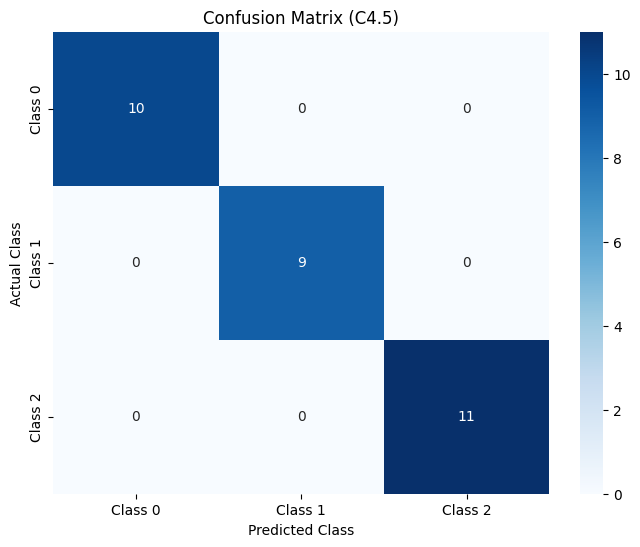

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_c45 = model_c45.predict(X_test_full)

print("Classification Report (C4.5):")
print(classification_report(y_test_full, y_pred_c45))

print("\nConfusion Matrix (C4.5):")
cm_c45 = confusion_matrix(y_test_full, y_pred_c45)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_c45, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (C4.5)')
plt.show()

Q - What is _ccp_alpha_ and why setting some value of _ccp_alpha_ implements similar to the C4.5 algorithm ?

Ans - _ccp_ means cost complexity pruning. It controls trade-off between tree's size and accuracy. It prevents decision tree from overfitting.
- smaller value of _ccp_alpha_ -> complex tree,

  higher value of _ccp_alpha_ -> smaller tree

- formula : Ralpha(T) = R(T) + alpha |T|
where,
Ralpha(T) is entropy,
alpha is ccp,
and |T| is no. of nodes, which we can also refer as complexity.

- It implements similar to C4.5 because...
both are bottom-up approaches aand both uses post-pruning, starting with a fully grown tree and then pruns that tree.
- C4.5 optimizes the tree by simplifying it to avoid the model capturing noise from the training data, which leads to better generalization, which is similar to ultimate goal of _ccp_alpha_ as well : producing a smaller and more interpretable tree that generlizes better on unseen data and avoids overfitting.